<a href="https://colab.research.google.com/github/ArthurRicartte/Fuzzy_Soccer_Score/blob/main/FuzzyFootballScore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ Fuzzy_Soccer_Score: Sistema Baseado em Conhecimento (Mamdani)

> **Segundo Miniprojeto de Sistemas Baseados em Conhecimento (SBC)**  
> **Desenvolvido por:** Arthur Ricartte e Felipe Rodrigues

---

### 📌 Sobre o Projeto
O **Fuzzy_Soccer_Score** é um sistema de inferência fuzzy (Mamdani) focado na avaliação de desempenho individual de jogadores de futebol. O modelo utiliza métricas de jogo e aplica um **pós-processamento híbrido** para penalizações disciplinares (cartões). Tivemos como inspiração a plataforma de estatísticas esportivas Sofascore.

---

### Variáveis de Entrada (Antecedentes)
* **Participação em Gols** `[0–5]`: Gols + Assistências na partida.
  * `baixa` `[0, 0, 1]` | `moderada` `[0, 1, 2]` | `alta` `[1, 2, 5, 5]`
* **Precisão de Passes** `[0–100%]`: Eficiência na distribuição de jogo.
  * `baixa` `[0, 0, 50, 70]` | `media` `[60, 75, 90]` | `excelente` `[80, 90, 100, 100]`
* **Desarmes** `[0–10]`: Ações defensivas bem-sucedidas.
  * `poucos` `[0, 0, 1, 3]` | `razoaveis` `[2, 4, 6]` | `muitos` `[5, 8, 10, 10]`
* **Duelos Ganhos** `[0–15]`: Disputas físicas e aéreas ganhas.
  * `poucos` `[0, 0, 2, 5]` | `medios` `[4, 7, 10]` | `muitos` `[8, 12, 15, 15]`

---

### Variável de Saída (Consequente)
* **Nota Base** `[3.0–10.0]`: Escala padrão de desempenho (Defuzzificação por **Centroide**).
  * `ruim` `[3.0, 3.0, 6.6]` | `boa` `[5.5, 6.6, 7.8]` | `ótima` `[6.6, 10.0, 10.0]`

---

### Regras Fuzzy

* **Nota Ruim**
  * **R1:** `participacao_gols.baixa` **e** `passes.baixa` $\rightarrow$ `nota.ruim`
  * **R2:** `participacao_gols.baixa` **e** `desarmes.poucos` **e** `duelos.poucos` $\rightarrow$ `nota.ruim`
  * **R3:** `participacao_gols.baixa` **e** `passes.baixa` **e** `desarmes.poucos` $\rightarrow$ `nota.ruim`

* **Nota Boa**
  * **R4:** `participacao_gols.baixa` **e** `passes.media` **e** (`desarmes.razoaveis` **ou** `duelos.medios`) $\rightarrow$ `nota.boa`
  * **R5:** `participacao_gols.baixa` **e** `passes.excelente` $\rightarrow$ `nota.boa`

* **Nota Ótima**
  * **R6:** `participacao_gols.moderada` **ou** `participacao_gols.alta` $\rightarrow$ `nota.ótima`
  * **R7:** `desarmes.muitos` **e** (`duelos.muitos` **ou** `desarmes.muitos`) $\rightarrow$ `nota.ótima`

---

### Pós-Processamento

* 1 Cartão Amarelo: Desconto de `-0.3`.
* 2º Cartão Amarelo / Vermelho Direto: Desconto de `-1.5`.
* Minutagem é um fator contextual registrado apenas para curiosidade.
* Nota final é estritamente mantida no intervalo `[3.0, 10.0]`.

In [2]:
# Instalando dependência para desenvolver o programa
!pip install -q scikit-fuzzy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.0 MB/s eta 0:00:00


In [3]:
#Importando as dependências necessárias para rodar o programa:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

print("Bibliotecas instaladas tudo ok!")

Bibliotecas instaladas tudo ok!


               ⚽ Relatório Fuzzy Soccer 🥅              
       Brasileirão 2026: Flamengo 3 x 0 Botafogo       
-------------------------------------------------------
👤 Jogador: Samuel Lino
📊 Estatísticas na partida:
   • 🕒 Minutagem           : 90 minutos
   • ⚽Participação em Gols : 2
   • 📋Precisão de Passes   : 90%
   • 🔒Desarmes             : 3
   • 💪Duelos Ganhos        : 9
   • 🟨Cartões Amarelos     : 0
   • 🟥Cartões Vermelhos    : 0
-------------------------------------------------------
📈 Nota Base (Motor Fuzzy)  : 8.8
⛔ Penalização Cartões      : 0.0
⭐ NOTA SOFASCORE FINAL     : 8.8

Plotagem da vairável notas e seus conjuntos:



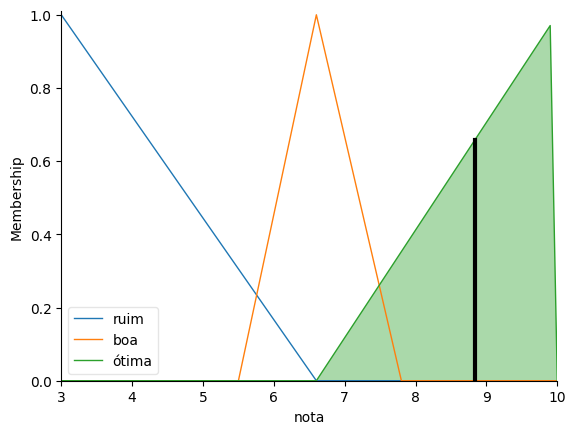

---------------------------------------------------------------------------

               ⚽ Relatório Fuzzy Soccer 🥅              
      Brasileirão 2026: Corinthias 1 x 3 Fluminese     
-------------------------------------------------------
👤 Jogador: Martinelli
📊 Estatísticas na partida:
   • 🕒 Minutagem           : 90 minutos
   • ⚽Participação em Gols : 1
   • 📋Precisão de Passes   : 91%
   • 🔒Desarmes             : 1
   • 💪Duelos Ganhos        : 5
   • 🟨Cartões Amarelos     : 1
   • 🟥Cartões Vermelhos    : 0
-------------------------------------------------------
📈 Nota Base (Motor Fuzzy)  : 8.8
⛔ Penalização Cartões      : 0.3
⭐ NOTA SOFASCORE FINAL     : 8.5

Plotagem da vairável notas e seus conjuntos:



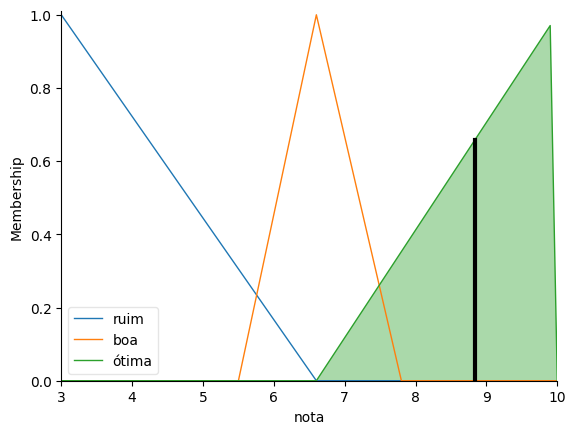

---------------------------------------------------------------------------

               ⚽ Relatório Fuzzy Soccer 🥅              
          Brasileirão 2026: Remo 1 x 2 Santos          
-------------------------------------------------------
👤 Jogador: Rodinei
📊 Estatísticas na partida:
   • 🕒 Minutagem           : 90 minutos
   • ⚽Participação em Gols : 0
   • 📋Precisão de Passes   : 80%
   • 🔒Desarmes             : 1
   • 💪Duelos Ganhos        : 5
   • 🟨Cartões Amarelos     : 2
   • 🟥Cartões Vermelhos    : 1 (Segundo amarelo -> vermelho indireto)
-------------------------------------------------------
📈 Nota Base (Motor Fuzzy)  : 6.6
⛔ Penalização Cartões      : 1.5
⭐ NOTA SOFASCORE FINAL     : 5.1

Plotagem da vairável notas e seus conjuntos:



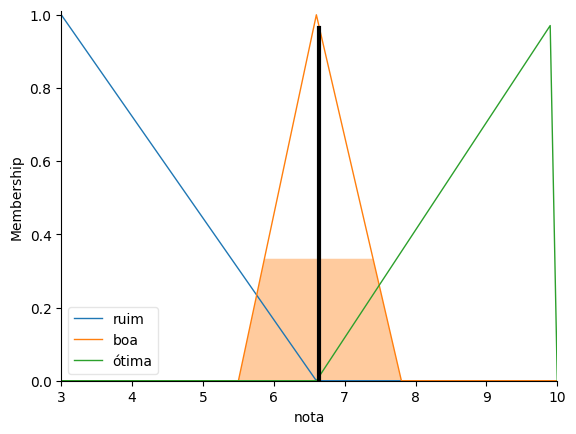

---------------------------------------------------------------------------

               ⚽ Relatório Fuzzy Soccer 🥅              
       Brasileirão 2026: Flamengo 0 x 3 Palmeiras      
-------------------------------------------------------
👤 Jogador: Carrascal
📊 Estatísticas na partida:
   • 🕒 Minutagem           : 21 minutos
   • ⚽Participação em Gols : 0
   • 📋Precisão de Passes   : 88%
   • 🔒Desarmes             : 0
   • 💪Duelos Ganhos        : 0
   • 🟨Cartões Amarelos     : 0
   • 🟥Cartões Vermelhos    : 1 (Vermelho direto)
-------------------------------------------------------
📈 Nota Base (Motor Fuzzy)  : 5.1
⛔ Penalização Cartões      : 1.5
⭐ NOTA SOFASCORE FINAL     : 3.6

Plotagem da vairável notas e seus conjuntos:



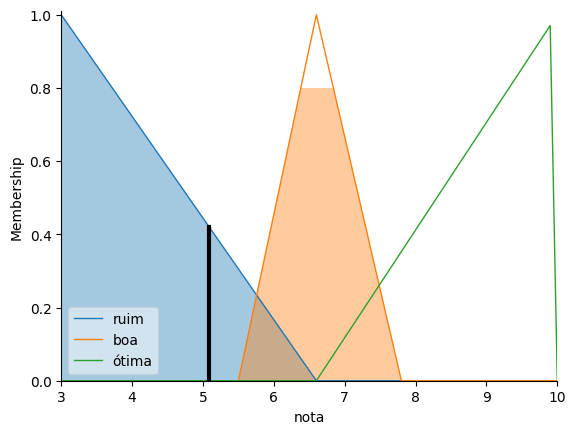

---------------------------------------------------------------------------



In [40]:
#Nos apps de nota de jogadores, existem penalizações para cartões amarelos e vermelhos:
PENALIZACAO_AMARELO = 0.3
PENALIZACAO_VERMELHO = 1.5

#Definindo os antecedentes:
participacao_gols = ctrl.Antecedent(np.arange(0, 6, 1), 'participacao_gols')          # 0 a 5 participações
precisao_passes = ctrl.Antecedent(np.arange(0, 101, 1), 'precisao_passes')     # 0 a 100% de precisão
desarmes = ctrl.Antecedent(np.arange(0, 11, 1), 'desarmes')   # 0 a 10 desarmes
duelos = ctrl.Antecedent(np.arange(0, 16, 1), 'duelos')     # 0 a 15 duelos ganhos

#Definindo o consequente (saída):
nota = ctrl.Consequent(np.arange(3, 10.1, 0.1), 'nota')       # 3 a 10 nota final

#Definindo os conjuntos de cada variável linguística:

# Participação em Gols (Gols + Assistências)
participacao_gols['baixa'] = fuzz.trimf(participacao_gols.universe, [0, 0, 1])
participacao_gols['moderada'] = fuzz.trimf(participacao_gols.universe, [0, 1, 2])
participacao_gols['alta'] = fuzz.trapmf(participacao_gols.universe, [1, 2, 5, 5])

# Precisão de Passes (%)
precisao_passes['baixa'] = fuzz.trapmf(precisao_passes.universe, [0, 0, 50, 70])
precisao_passes['media'] = fuzz.trimf(precisao_passes.universe, [60, 75, 90])
precisao_passes['excelente'] = fuzz.trapmf(precisao_passes.universe, [80, 90, 100, 100])

# Desarmes / Ações Defensivas
desarmes['poucos'] = fuzz.trapmf(desarmes.universe, [0, 0, 1, 3])
desarmes['razoaveis'] = fuzz.trimf(desarmes.universe, [2, 4, 6])
desarmes['muitos'] = fuzz.trapmf(desarmes.universe, [5, 8, 10, 10])

# Duelos Ganhos
duelos['poucos'] = fuzz.trapmf(duelos.universe, [0, 0, 2, 5])
duelos['medios'] = fuzz.trimf(duelos.universe, [4, 7, 10])
duelos['muitos'] = fuzz.trapmf(duelos.universe, [8, 12, 15, 15])

# Nota Sofascore Base (Pico estatístico calibrado em 6.6)
nota['ruim'] = fuzz.trimf(nota.universe, [3.0, 3.0, 6.6])
nota['boa'] = fuzz.trimf(nota.universe, [5.5, 6.6, 7.8])
nota['ótima'] = fuzz.trimf(nota.universe, [6.6, 10.0, 10.0])

# Regras fuzzy:

# Regras para enquadrar notas ruins:
#o uso de participação em gols nessas 3 primeiras regras serve para evitar que um jogador que fez muitos gols ative elas
r1 = ctrl.Rule(participacao_gols['baixa'] & precisao_passes['baixa'], nota['ruim'])
r2 = ctrl.Rule(desarmes['poucos'] & duelos['poucos'] & participacao_gols['baixa'], nota['ruim'])
r3 = ctrl.Rule(precisao_passes['baixa'] & desarmes['poucos'] & participacao_gols['baixa'], nota['ruim'])

# Regras para nota mediana (foca em jogadores que não fizeram gols mas as outras estatísticas foram boas/medianas):
r4 = ctrl.Rule(participacao_gols['baixa'] & precisao_passes['media'] & (desarmes['razoaveis'] | duelos['medios']), nota['boa'])
r5 = ctrl.Rule(participacao_gols['baixa'] & precisao_passes['excelente'], nota['boa'])
r6 = ctrl.Rule(participacao_gols['baixa'] & (desarmes['muitos'] | duelos['muitos']), nota['boa'])

# Regras para as melhores notas:6
r7 = ctrl.Rule(participacao_gols['alta'] | participacao_gols['moderada'], nota['ótima'])
r8 = ctrl.Rule(precisao_passes['excelente'] & (desarmes['muitos'] | duelos['muitos']), nota['ótima'])
# Criando o sistema de controle com todas as regras:
sistema = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8])
sim = ctrl.ControlSystemSimulation(sistema)

# =================================================================================================================================================================
# Criando função para modularizar o código do input de dados:
def avaliar_jogador(simulador, nome, partida, participacao_gols, passes, desarmes, duelos, cartoes_amarelos=0, cartoes_vermelhos=0, minutagem=90):

    # Atribuição dos antecedentes ao simulador:
    simulador.input['participacao_gols'] = participacao_gols
    simulador.input['precisao_passes'] = passes
    simulador.input['desarmes'] = desarmes
    simulador.input['duelos'] = duelos

    # Execução do motor fuzzy:
    simulador.compute()
    nota_base = simulador.output['nota']

    # Penalização por cartões:
    tipo_expulsao = None
    penalizacao = 0

    if cartoes_amarelos >= 2:
      penalizacao = 1.5
      tipo_expulsao = "Segundo amarelo -> vermelho indireto"
      cartoes_vermelhos = 1
    elif cartoes_vermelhos >= 1:
      penalizacao = 1.5
      tipo_expulsao = "Vermelho direto"
    elif cartoes_amarelos == 1:
      penalizacao = 0.3
    else:
      penalizacao = 0.0

  # Definindo a nota final (adicionando a penalização dos cartões):
    nota_final = max(3.0, min(10.0, nota_base - penalizacao))

  # Retornando todas as infos do jogador + os novos dados calculados:
    return {
        'nome': nome,
        'partida': partida,
        'estatisticas': {
            'participacao_gols': participacao_gols,
            'passes': passes,
            'desarmes': desarmes,
            'duelos': duelos,
            'cartoes_amarelos': cartoes_amarelos,
            'cartoes_vermelhos': cartoes_vermelhos,
            'minutagem': minutagem,
            'tipo_expulsao': tipo_expulsao
        },
        'nota_base': nota_base,
        'penalizacao': penalizacao,
        'nota_final': nota_final
    }


# =================================================================================================================================================================
# Função para exibir relatório do jogador:
def exibir_relatorio(resultado_avaliacao, consequente_nota=None, simulador=None, exibir_grafico=False):
  #Definindo uma largura para exibição:
  largura = 55

  print("=" * largura)
  print("⚽ Relatório Fuzzy Soccer 🥅".center(largura))
  print("=" * largura)
  print(resultado_avaliacao['partida'].center(largura))
  print("-" * largura)

  estatisticas = resultado_avaliacao['estatisticas']
  print(f"👤 Jogador: {resultado_avaliacao['nome']}")
  print(f"📊 Estatísticas na partida:")
  print(f"   • 🕒 Minutagem           : {estatisticas['minutagem']} minutos")
  print(f"   • ⚽Participação em Gols : {estatisticas['participacao_gols']}")
  print(f"   • 📋Precisão de Passes   : {estatisticas['passes']}%")
  print(f"   • 🔒Desarmes             : {estatisticas['desarmes']}")
  print(f"   • 💪Duelos Ganhos        : {estatisticas['duelos']}")
  print(f"   • 🟨Cartões Amarelos     : {estatisticas['cartoes_amarelos']}")

  # Exibição dos cartões vermelhos + tipo de expulsão:
  if estatisticas['tipo_expulsao']:
      print(f"   • 🟥Cartões Vermelhos    : {estatisticas['cartoes_vermelhos']} ({estatisticas['tipo_expulsao']})")
  else:
      print(f"   • 🟥Cartões Vermelhos    : {estatisticas['cartoes_vermelhos']}")

  print("-" * largura)
  print(f"📈 Nota Base (Motor Fuzzy)  : {resultado_avaliacao['nota_base']:.1f}")
  print(f"⛔ Penalização Cartões      : {resultado_avaliacao['penalizacao']:.1f}")
  print(f"⭐ NOTA SOFASCORE FINAL     : {resultado_avaliacao['nota_final']:.1f}")
  print("=" * largura + "\n")

  # Exibição opcional do gráfico das notas:
  if exibir_grafico and consequente_nota is not None and simulador is not None:
      print("Plotagem da vairável notas e seus conjuntos:\n")
      consequente_nota.view(sim=simulador)
      plt.show()
      print("-" * 75 + "\n")
# =================================================================================================================================================================


# ===================
# Adicionando testes:
# ===================

jogador1 = avaliar_jogador(
    simulador=sim,
    nome = "Samuel Lino",
    partida = "Brasileirão 2026: Flamengo 3 x 0 Botafogo",
    participacao_gols=2,
    passes=90,
    desarmes=3,
    duelos=9,
    cartoes_amarelos=0,
    cartoes_vermelhos=0,
    minutagem = 90
)

exibir_relatorio(jogador1, nota, sim, True) # Assim que adiciona o teste já tem que executar (senão, ele repete o mesmo gráfico em todos)

jogador2 = avaliar_jogador(
    simulador=sim,
    nome = "Martinelli",
    partida = "Brasileirão 2026: Corinthias 1 x 3 Fluminese",
    participacao_gols=1,
    passes=91,
    desarmes=1,
    duelos=5,
    cartoes_amarelos=1,
    cartoes_vermelhos=0,
    minutagem = 90
)
exibir_relatorio(jogador2, nota, sim, True)

jogador3 = avaliar_jogador(
    simulador=sim,
    nome = "Rodinei",
    partida = "Brasileirão 2026: Remo 1 x 2 Santos",
    participacao_gols=0,
    passes=80,
    desarmes=1,
    duelos=5,
    cartoes_amarelos=1,
    cartoes_vermelhos=0,
    minutagem = 90
)
exibir_relatorio(jogador3, nota, sim, True)

jogador4 = avaliar_jogador(
    simulador=sim,
    nome = "Carrascal",
    partida = "Brasileirão 2026: Flamengo 0 x 3 Palmeiras",
    participacao_gols=0,
    passes=88,
    desarmes=0,
    duelos=0,
    cartoes_amarelos=0,
    cartoes_vermelhos=1,
    minutagem = 21
)
exibir_relatorio(jogador4, nota, sim, True)